In [9]:
import sys
print("EXE:", sys.executable)
print("PATH:", sys.path[:3], "…")


EXE: c:\Users\Luca Agius\AppData\Local\Programs\Python\Python313\python.exe
PATH: ['c:\\Users\\Luca Agius\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'c:\\Users\\Luca Agius\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'c:\\Users\\Luca Agius\\AppData\\Local\\Programs\\Python\\Python313\\Lib'] …


In [5]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from itertools import islice

# 1) Read your soil contamination data (CSV with lat/lon)
soil_csv = "soil_pollution_diseases_interpolated_synthetic_corrected.csv"
soil_df = pd.read_csv(soil_csv)
print(soil_df.columns)

# list the columns to remove
cols_to_remove = [
    'Soil_Organic_Matter_%',
    'Region',
    'Case_ID',
    'Case_Resolved',
    'Follow_Up_Required',
    'Gender_Most_Affected',
    'Disease_Severity',
    'Health_Symptoms',
    'Date_Reported',
    'Country',
    'Age_Group_Affected'
]

# read in your DataFrame
soil_csv = "soil_pollution_diseases_interpolated_synthetic_corrected.csv"
soil_df = pd.read_csv(soil_csv)

# drop the unwanted features
soil_df = soil_df.drop(columns=cols_to_remove)

# (optional) verify
print(soil_df.columns)

# after dropping the unwanted columns, save to CSV:
soil_df.to_csv("soil_csv_pre-processed.csv", index=False)



Index(['Case_ID', 'Date_Reported', 'Region', 'Country', 'Pollutant_Type',
       'Pollutant_Concentration_mg_kg', 'Soil_pH', 'Temperature_C',
       'Humidity_%', 'Rainfall_mm', 'Crop_Type', 'Farming_Practice',
       'Nearby_Industry', 'Water_Source_Type', 'Soil_Texture',
       'Soil_Organic_Matter_%', 'Disease_Type', 'Disease_Severity',
       'Health_Symptoms', 'Age_Group_Affected', 'Gender_Most_Affected',
       'Mitigation_Measure', 'Case_Resolved', 'Follow_Up_Required'],
      dtype='object')
Index(['Pollutant_Type', 'Pollutant_Concentration_mg_kg', 'Soil_pH',
       'Temperature_C', 'Humidity_%', 'Rainfall_mm', 'Crop_Type',
       'Farming_Practice', 'Nearby_Industry', 'Water_Source_Type',
       'Soil_Texture', 'Disease_Type', 'Mitigation_Measure'],
      dtype='object')


In [11]:
import fiona

shp = r"C:\Users\Luca Agius\OneDrive - NSW Department of Education\Documents\Uni\ENGG2112\Coding Tutorials\land_nswlanduse2017v1p5\NSWLanduse2017_Ver1_5_20230921.shp"

with fiona.open(shp, "r") as src:
    print("Driver:", src.driver)
    print("CRS:",    src.crs)
    print("Fields:", src.schema["properties"])
    print("Feature count:", len(src))
    crs = src.crs
    sample_feats = list(islice(src, 200000))

Driver: ESRI Shapefile
CRS: EPSG:4283
Fields: {'SecondaryA': 'int32:5', 'TertiaryAL': 'int32:5', 'SHAPE_Leng': 'float:19.11', 'SHAPE_Area': 'float:19.11', 'Commoditie': 'int32:5', 'Area_Ha': 'float:19.11', 'Note': 'str:100', 'Secondary': 'str:60', 'Tertiary': 'str:60', 'Commodity': 'str:20'}
Feature count: 1202207


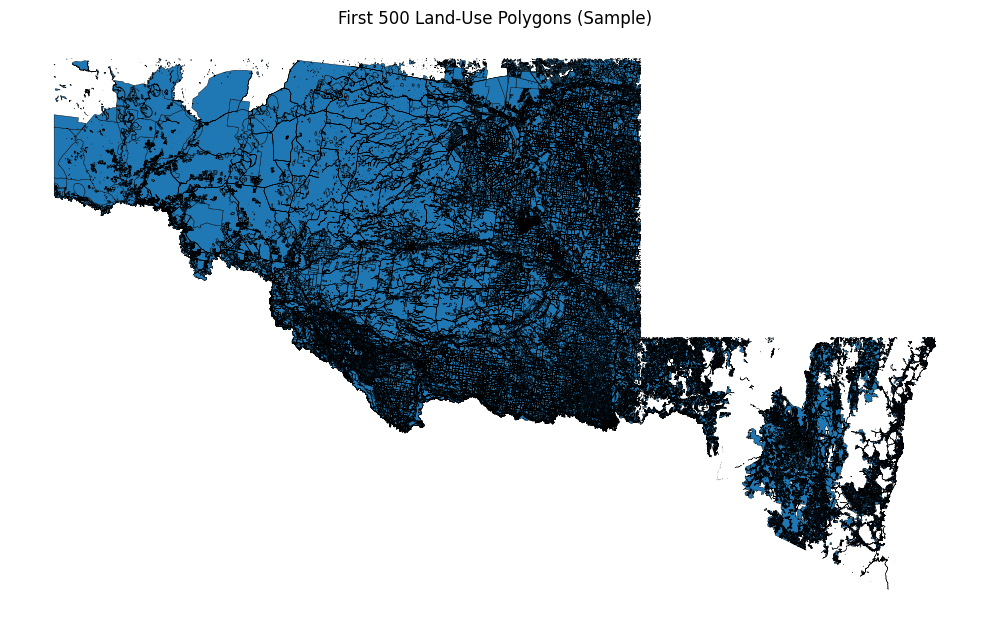

In [ ]:
gdf_sample = gpd.GeoDataFrame.from_features(sample_feats, crs=crs)

# 4) Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_sample.plot(ax=ax, edgecolor="black", linewidth=0.3)
ax.set_title("First 500 Land-Use Polygons (Sample)")
ax.set_axis_off()    # hide axes for clarity
plt.tight_layout()
plt.show()

In [12]:
# 2) Open with Fiona and inspect schema
with fiona.open(shp, "r") as src:
    props = src.schema["properties"]
    print("Available fields:")
    for name, dtype in props.items():
        print(f"  • {name} : {dtype}")
    print("Total features:", len(src))

    # 3) Identify the exact field name for Tertiary commodities from the list above.
    tertiary_field = "Tertiary"  # ← e.g. "TERT_COMM" or similar

    unique_vals = set()
    for feat in islice(src, 200_000):
        v = feat["properties"].get(tertiary_field)
        if v is not None:
            unique_vals.add(v)

print(f"\nUnique values in '{tertiary_field}':")
for val in sorted(unique_vals):
    print(f"  - {val}")

Available fields:
  • SecondaryA : int32:5
  • TertiaryAL : int32:5
  • SHAPE_Leng : float:19.11
  • SHAPE_Area : float:19.11
  • Commoditie : int32:5
  • Area_Ha : float:19.11
  • Note : str:100
  • Secondary : str:60
  • Tertiary : str:60
  • Commodity : str:20
Total features: 1202207

Unique values in 'Tertiary':
  - 1.1.1 Strict nature reserves
  - 1.1.3 National park
  - 1.1.7 Other conserved area
  - 1.2.0 Managed resource protection
  - 1.2.1 Biodiversity
  - 1.2.2 Surface water supply
  - 1.2.4 Landscape
  - 1.3.0 Other minimal use
  - 1.3.1 Defence land - natural areas
  - 1.3.2 Stock route
  - 1.3.3 Residual native cover
  - 1.3.4 Rehabilitation
  - 2.1.0 Grazing native vegetation
  - 2.2.0 Production native forests
  - 3.1.0 Plantation forests
  - 3.1.1 Hardwood plantation forestry
  - 3.1.2 Softwood plantation forestry
  - 3.1.3 Other forest plantation
  - 3.1.4 Environmental forest plantation
  - 3.2.0 Grazing modified pastures
  - 3.2.1 Native/exotic pasture mosaic
  - 3.

In [13]:
# 3) Get unique Nearby_Industry values (dropping any NaNs)
unique_industries = soil_df["Nearby_Industry"].dropna().unique()

# 4) (Optional) Sort and print them
for industry in sorted(unique_industries):
    print(industry)



Agriculture
Chemical
Mining
Textile


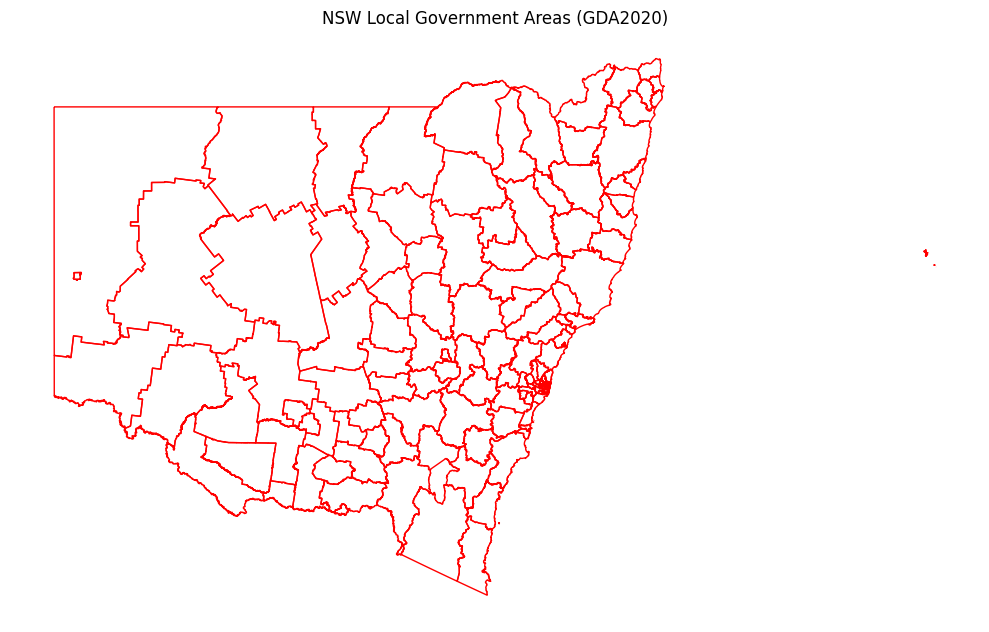

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Path to your LGA shapefile
shp_path = r"C:\Users\Luca Agius\OneDrive - NSW Department of Education\Documents\Uni\ENGG2112\Coding Tutorials\GDA2020\nsw_lga.shp"

# 2) Read into a GeoDataFrame
lga_gdf = gpd.read_file(shp_path)

# 3) Plot boundaries in red (no fill)
fig, ax = plt.subplots(figsize=(10, 10))
lga_gdf.plot(
    ax=ax,
    edgecolor="red",
    facecolor="none",
    linewidth=1
)

# 4) Tidy up
ax.set_title("NSW Local Government Areas (GDA2020)")
ax.axis("off")
plt.tight_layout()
plt.show()


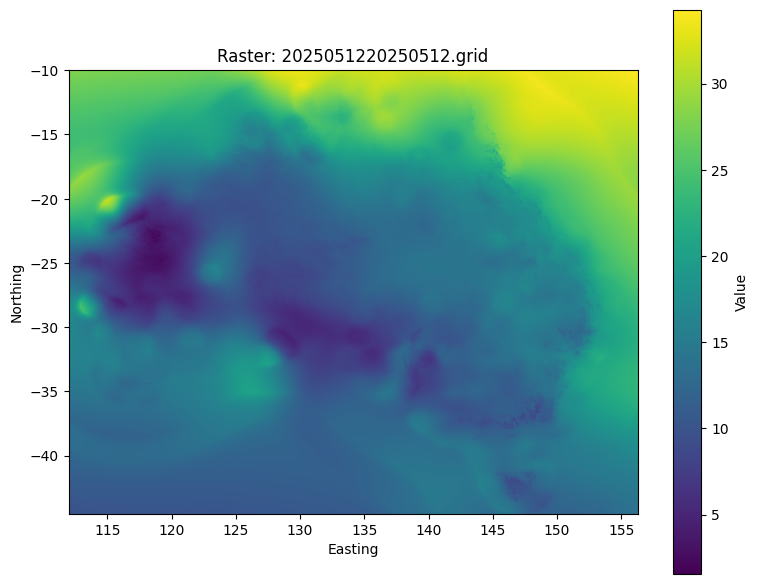

In [24]:
import rasterio

# 1) Path to your grid file
grid_path = r"C:\Users\Luca Agius\OneDrive - NSW Department of Education\Documents\Uni\ENGG2112\Coding Tutorials\2025051220250512.grid\2025051220250512.grid"

# 2) Open with Rasterio
with rasterio.open(grid_path) as src:
    # Read the first (and only) band
    data = src.read(1)
    # Get the bounds for correct axis extents
    left, bottom, right, top = src.bounds

# 3) Plot with Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    data,
    extent=(left, right, bottom, top),
    origin="upper",
    cmap="viridis"          # change colormap as you like
)
ax.set_title("Raster: 2025051220250512.grid")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
fig.colorbar(im, ax=ax, label="Value")

plt.tight_layout()
plt.show()


Assigned GRID CRS: EPSG:7844
Raster EPSG: 7844


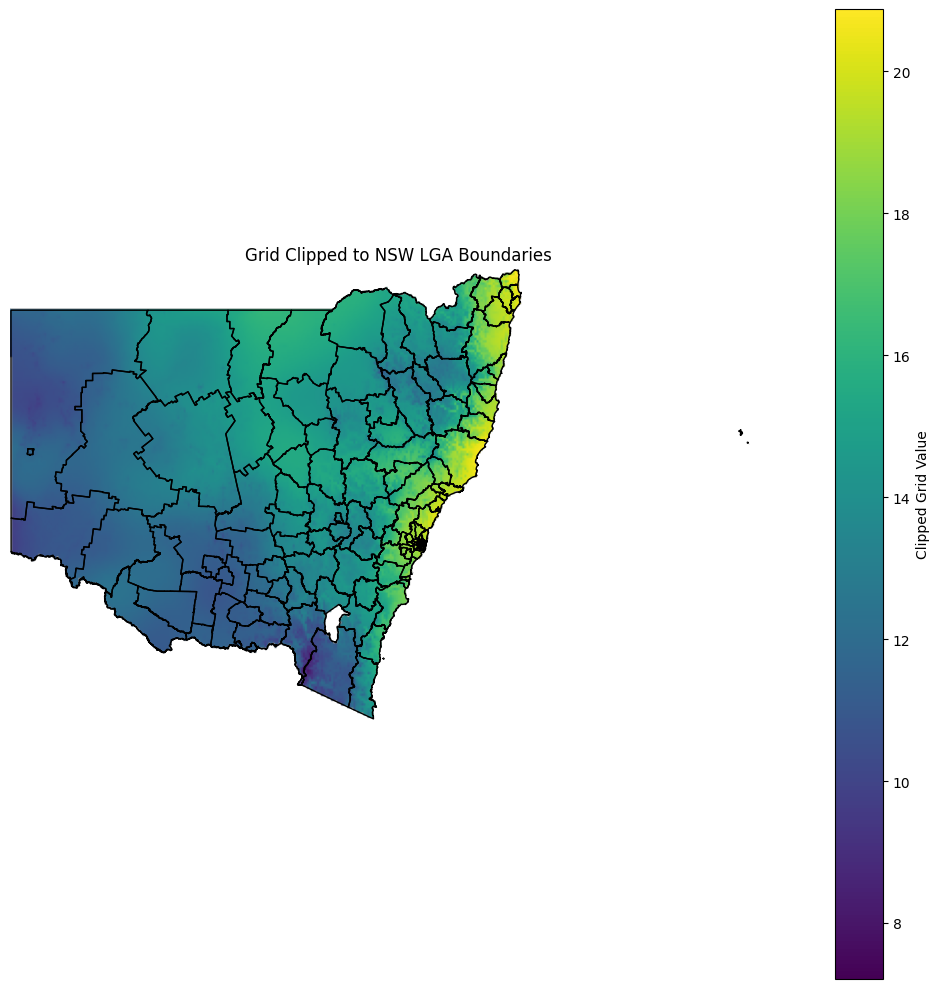

In [33]:
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.transform import array_bounds
from rasterio.crs import CRS
from shapely.geometry import mapping

# ——————————————————————————————————————
# 1) Paths to your data
# ——————————————————————————————————————
grid_path = r"C:\Users\Luca Agius\OneDrive - NSW Department of Education\Documents\Uni\ENGG2112\Coding Tutorials\2025051220250512.grid\2025051220250512.grid"
lga_shp   = r"C:\Users\Luca Agius\OneDrive - NSW Department of Education\Documents\Uni\ENGG2112\Coding Tutorials\GDA2020\nsw_lga.shp"

# load LGA and ensure it has a CRS
lga = gpd.read_file(lga_shp)
if lga.crs is None:
    lga = lga.set_crs(epsg=7844)

# open the grid and *assign* a CRS if missing
with rasterio.open(grid_path) as src:
    if src.crs is None:
        raster_crs = CRS.from_epsg(7844)   # ← change 7844 to whatever yours should be
        print("Assigned GRID CRS:", raster_crs)
    else:
        raster_crs = src.crs

    epsg = raster_crs.to_epsg()
    print("Raster EPSG:", epsg)

# reproject LGA to match
lga = lga.to_crs(raster_crs)

# mask as before
shapes = [mapping(geom) for geom in lga.geometry]
with rasterio.open(grid_path) as src:
    clipped_arr, clipped_transform = mask(src, shapes, crop=True, nodata=np.nan)
    data = clipped_arr[0]

# plot
n_rows, n_cols = data.shape
xmin, ymin, xmax, ymax = array_bounds(n_rows, n_cols, clipped_transform)

fig, ax = plt.subplots(figsize=(10,10))
im = ax.imshow(
    data,
    extent=(xmin, xmax, ymin, ymax),
    origin="upper",
    cmap="viridis",
    vmin=np.nanmin(data),
    vmax=np.nanmax(data)
)
fig.colorbar(im, ax=ax, label="Clipped Grid Value")
lga.boundary.plot(ax=ax, edgecolor="black", linewidth=1)
ax.set_title("Grid Clipped to NSW LGA Boundaries")
ax.axis("off")
plt.tight_layout()
plt.show()

In [59]:
# ── 2) Read sites in raw WGS84 ──
sites_df = pd.read_excel(
    r"Contaminated-sites-list-Excel-April-2025.xlsx",
    sheet_name="9 April 2025",
    engine="openpyxl"
)

# ── 3) Inspect the actual column names ──
print("Columns in DataFrame:")
print(sites_df.columns.tolist())

# (Look through that list for the column corresponding to contaminant activity,
# e.g. it might be named "Contaminant Activity Type" or "ActivityType", etc.)

# ── 4) Filter out any rows where the activity is Unclassified ──
# Replace 'YOUR_COLUMN_NAME' below with the exact column name you spotted above.
col = 'ContaminationActivityType'  

sites_df = sites_df[
    ~sites_df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq('unclassified')
].copy()

# ── 5) (Optional) reset the index and verify ──
sites_df.reset_index(drop=True, inplace=True)
print(f"Rows after dropping 'Unclassified' in {col}:", len(sites_df))
print(sites_df[col].value_counts())


Columns in DataFrame:
['Suburb', 'SiteName', 'Address', 'ContaminationActivityType', 'ManagementClass', 'Latitude', 'Longitude']
Rows after dropping 'Unclassified' in ContaminationActivityType: 1858
ContaminationActivityType
Service Station      908
Other Industry       368
Other Petroleum      240
Landfill             128
Metal Industry        74
Gasworks              68
Chemical Industry     63
Cattle Dip             9
Name: count, dtype: int64


C:\Users\Luca Agius\AppData\Local\Temp\ipykernel_21280\4048158219.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lga_union = lga_gdf.geometry.unary_union


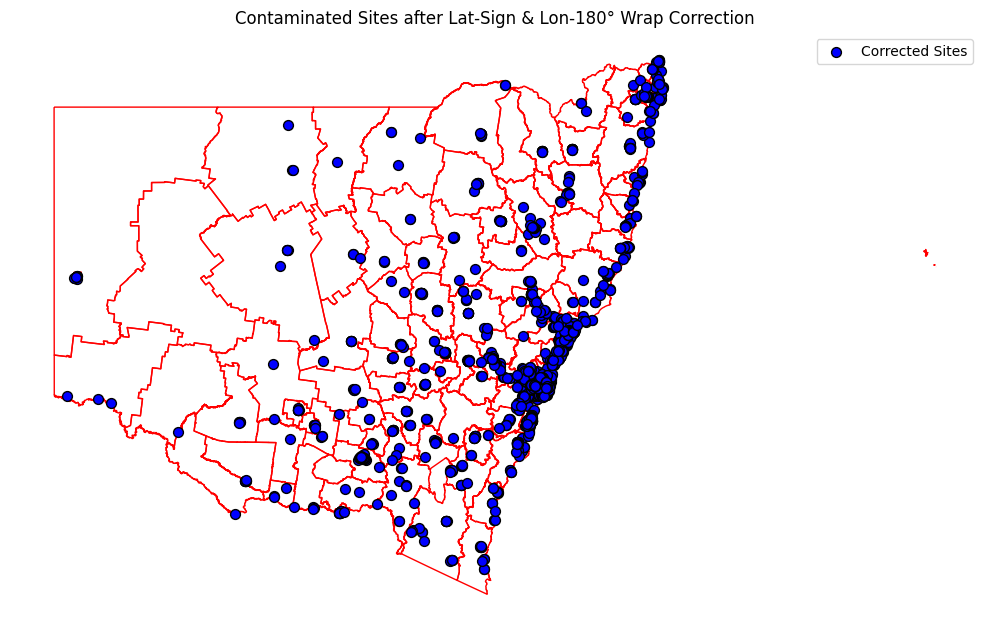

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# ── 1) Load NSW LGA and capture its CRS ──
lga_gdf = gpd.read_file(r"C:\Users\Luca Agius\OneDrive - NSW Department of Education\Documents\Uni\ENGG2112\Coding Tutorials\GDA2020\nsw_lga.shp")
if lga_gdf.crs is None:
    lga_gdf = lga_gdf.set_crs(epsg=7844)
lga_crs   = lga_gdf.crs
lga_union = lga_gdf.geometry.unary_union


gdf_wgs = gpd.GeoDataFrame(
    sites_df,
    geometry=gpd.points_from_xy(sites_df.Longitude, sites_df.Latitude),
    crs="EPSG:4326"
)

# ── 3) Project & flag out-of-bounds ──
gdf = gdf_wgs.to_crs(lga_crs)
gdf['in_nsw'] = gdf.geometry.within(lga_union)

# ── 4) Auto-correct lat/lon typos ──
# a) Flip any positive latitudes
mask_lat = (~gdf['in_nsw']) & (gdf_wgs['Latitude'] > 0)
gdf_wgs.loc[mask_lat, 'Latitude'] *= -1

# b) “180° wrap” for any negative longitudes
mask_lon = (~gdf['in_nsw']) & (gdf_wgs['Longitude'] < 0)
gdf_wgs.loc[mask_lon, 'Longitude'] = (gdf_wgs.loc[mask_lon, 'Longitude'] + 180) % 360

# ── 5) Rebuild & reproject after correction ──
gdf_fixed = gpd.GeoDataFrame(
    gdf_wgs.drop(columns='geometry'),
    geometry=gpd.points_from_xy(gdf_wgs.Longitude, gdf_wgs.Latitude),
    crs="EPSG:4326"
).to_crs(lga_crs)
gdf_fixed['in_nsw'] = gdf_fixed.geometry.within(lga_union)

# ── 6) Plot only the in-bounds (corrected) sites ──
fig, ax = plt.subplots(figsize=(10,10))
lga_gdf.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1)

gdf_fixed[gdf_fixed['in_nsw']].plot(
    ax=ax,
    marker="o",
    color="blue",
    edgecolor="black",
    markersize=50,
    label="Corrected Sites"
)

ax.legend()
ax.set_title("Contaminated Sites after Lat-Sign & Lon-180° Wrap Correction")
ax.axis("off")
plt.tight_layout()
plt.show()


In [51]:
typesofContaminantActivity = sites_df["ContaminationActivityType"].dropna().unique()
print(typesofContaminantActivity)
typesofContaminants = soil_df["Pollutant_Type"].dropna().unique()
print(typesofContaminants)

['Gasworks' 'Other Industry' 'Landfill' 'Service Station'
 'Other Petroleum' 'Unclassified' 'Metal Industry' 'Chemical Industry'
 'Cattle Dip']
['Lead' 'Pesticides' 'Mercury' 'Chromium' 'Arsenic' 'Cadmium']
